<a href="https://colab.research.google.com/github/RMoulla/BDA_Avril26/blob/main/TP_German_Credit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Manipulation de données tabulaires avec Pandas  


Ce notebook a pour objectif de te faire pratiquer les opérations fondamentales de **manipulation de données tabulaires avec Pandas** à partir d'un dataset réaliste.

### Compétences visées
- charger un fichier CSV
- inspecter la structure d'un DataFrame
- nettoyer des données
- gérer les valeurs manquantes
- filtrer, trier, sélectionner
- créer de nouvelles variables
- agréger avec `groupby`
- réaliser des tableaux croisés
- tirer quelques premiers enseignements métier

### Dataset
Le fichier utilisé est `german_credit_data.csv`.


## 1. Import des bibliothèques

Dans cette première partie, on importe les bibliothèques nécessaires.  
Ici, nous utiliserons principalement **Pandas** et, ponctuellement, **NumPy**.


In [ ]:
import pandas as pd
import numpy as np


In [ ]:
pip install gradio -q

## 2. Chargement des données

On charge maintenant le fichier CSV dans un DataFrame Pandas.


In [ ]:
df = pd.read_csv("german_credit_data.csv")
df.head()


,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,0,67,male,2,own,NaN,little,1169,6,radio/TV
1,1,22,female,2,own,little,moderate,5951,48,radio/TV
2,2,49,male,1,own,little,NaN,2096,12,education
3,3,45,male,2,free,little,little,7882,42,furniture/equipment
4,4,53,male,2,free,little,little,4870,24,car


## 3. Première inspection du dataset

Avant toute manipulation, il faut toujours commencer par comprendre la structure des données.

### À observer
- le nombre de lignes
- le nombre de colonnes
- les noms des variables
- les types de variables
- la présence éventuelle de valeurs manquantes


In [ ]:
df.shape


(1000, 10)

In [ ]:
df.columns


Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose'],
      dtype='object')

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
dtypes: int64(5), object(5)
memory usage: 78.3+ KB


In [ ]:
df.describe()


,Unnamed: 0,Age,Job,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,499.500000,35.546000,1.904000,3271.258000,20.903000
std,288.819436,11.375469,0.653614,2822.736876,12.058814
min,0.000000,19.000000,0.000000,250.000000,4.000000
25%,249.750000,27.000000,2.000000,1365.500000,12.000000
50%,499.500000,33.000000,2.000000,2319.500000,18.000000
75%,749.250000,42.000000,2.000000,3972.250000,24.000000
max,999.000000,75.000000,3.000000,18424.000000,72.000000


### Questions
1. Combien y a-t-il de lignes dans le dataset ?
2. Combien y a-t-il de colonnes ?
3. Quelles sont les variables numériques ?
4. Quelles sont les variables catégorielles ?


## 4. Nettoyage initial

On remarque généralement dans ce dataset une colonne `Unnamed: 0`, qui correspond à un ancien index sauvegardé dans le fichier CSV.

Cette colonne n'apporte pas d'information utile pour l'analyse. On la supprime.


In [ ]:
df = df.drop(columns=["Unnamed: 0"], errors="ignore")
df.head()


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,67,male,2,own,NaN,little,1169,6,radio/TV
1,22,female,2,own,little,moderate,5951,48,radio/TV
2,49,male,1,own,little,NaN,2096,12,education
3,45,male,2,free,little,little,7882,42,furniture/equipment
4,53,male,2,free,little,little,4870,24,car


## 5. Étude des valeurs manquantes

Les valeurs manquantes sont un point central en analyse de données.  
Avant de les traiter, il faut d'abord les repérer.


In [ ]:
df.isna().sum()


,0
Age,0
Sex,0
Job,0
Housing,0
Saving accounts,183
Checking account,394
Credit amount,0
Duration,0
Purpose,0


### Interprétation
Dans ce dataset, les colonnes `Saving accounts` et `Checking account` contiennent des valeurs manquantes.

Dans un contexte réel, une valeur manquante peut vouloir dire plusieurs choses :
- information non renseignée
- absence réelle de compte
- problème de collecte
- donnée perdue

Dans ce notebook, nous allons choisir une stratégie simple : remplacer les valeurs manquantes par une catégorie explicite.


In [ ]:
df[df.isna().any(axis=1)]

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,67,male,2,own,NaN,little,1169,6,radio/TV
2,49,male,1,own,little,NaN,2096,12,education
5,35,male,1,free,NaN,NaN,9055,36,education
6,53,male,2,own,quite rich,NaN,2835,24,furniture/equipment
8,61,male,1,own,rich,NaN,3059,12,radio/TV
...,...,...,...,...,...,...,...,...,...
991,34,male,1,own,moderate,NaN,1569,15,radio/TV
992,23,male,1,rent,NaN,little,1936,18,radio/TV
994,50,male,2,own,NaN,NaN,2390,12,car
995,31,female,1,own,little,NaN,1736,12,furniture/equipment


In [ ]:
df[df["Saving accounts"].isna() & df["Checking account"].isna()]

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
5,35,male,1,free,NaN,NaN,9055,36,education
16,53,male,2,own,NaN,NaN,2424,24,radio/TV
24,26,male,2,own,NaN,NaN,2069,10,furniture/equipment
33,57,male,1,rent,NaN,NaN,1264,12,business
53,31,male,2,own,NaN,NaN,3378,18,car
...,...,...,...,...,...,...,...,...,...
947,38,male,3,own,NaN,NaN,2859,12,car
962,29,male,2,own,NaN,NaN,3556,15,car
968,29,male,2,rent,NaN,NaN,7166,42,radio/TV
990,37,male,1,own,NaN,NaN,3565,12,education


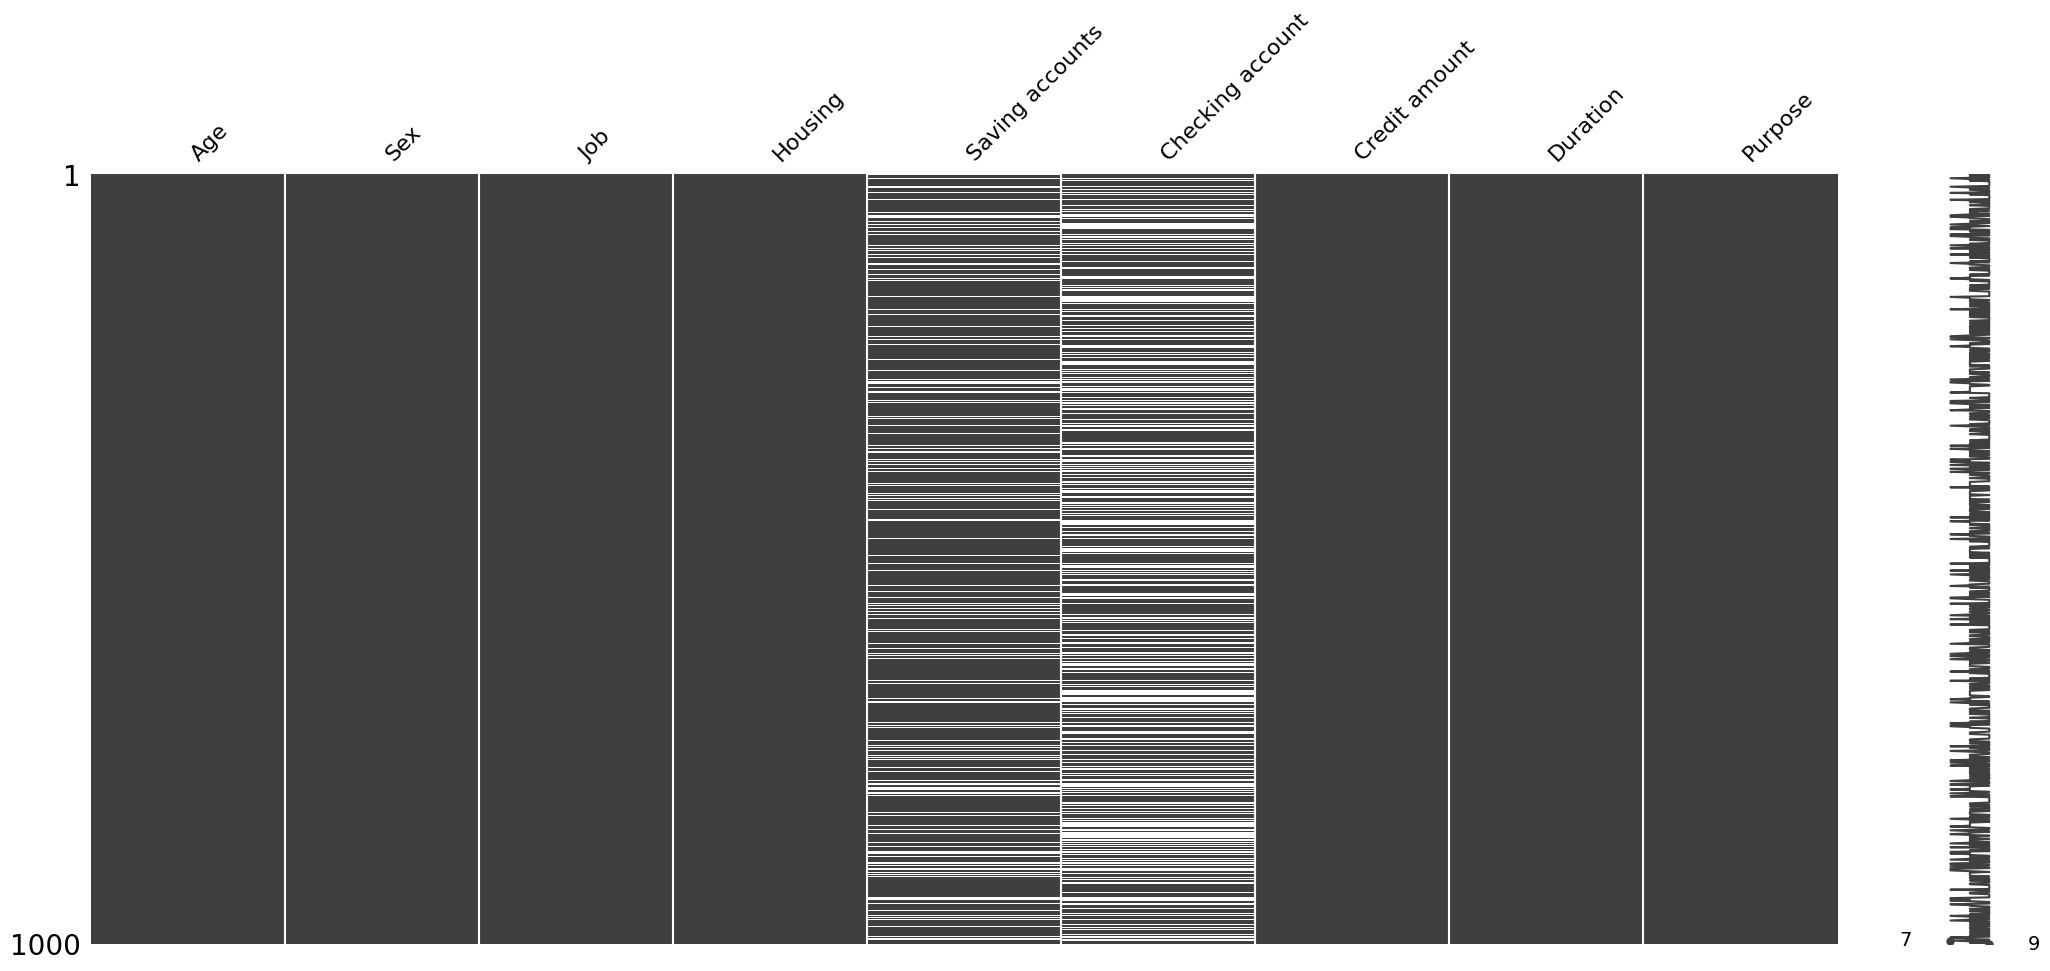

In [ ]:
import matplotlib.pyplot as plt
import missingno as msno
msno.matrix(df)
plt.show()

In [ ]:
df = df.fillna("no_info")

df.isna().sum()


,0
Age,0
Sex,0
Job,0
Housing,0
Saving accounts,0
Checking account,0
Credit amount,0
Duration,0
Purpose,0


### Exercice
Pourquoi peut-il être préférable, ici, de remplacer les valeurs manquantes par `no_info` plutôt que de supprimer les lignes concernées ?


## 6. Sélection de colonnes

Pandas permet de sélectionner une ou plusieurs colonnes facilement.


In [ ]:
df["Age"].head()

,Age
0,67
1,22
2,49
3,45
4,53


In [ ]:
df[["Age", "Sex", "Credit amount"]].head()


,Age,Sex,Credit amount
0,67,male,1169
1,22,female,5951
2,49,male,2096
3,45,male,7882
4,53,male,4870


## 7. Filtrage de lignes

On peut filtrer les lignes du dataset à partir de conditions logiques.


In [ ]:
df[df["Age"] > 50].head()


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,67,male,2,own,no_info,little,1169,6,radio/TV
4,53,male,2,free,little,little,4870,24,car
6,53,male,2,own,quite rich,no_info,2835,24,furniture/equipment
8,61,male,1,own,rich,no_info,3059,12,radio/TV
13,60,male,1,own,little,little,1199,24,car


In [ ]:
df[df["Credit amount"] > 10000].head()


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
18,44,female,3,free,little,moderate,12579,24,car
63,25,male,2,own,little,moderate,14421,48,business
87,47,male,2,free,moderate,moderate,12612,36,education
95,58,male,2,rent,little,moderate,15945,54,business
105,39,male,3,own,little,moderate,11938,24,vacation/others


In [ ]:
df[(df["Age"] < 30) & (df["Credit amount"] > 5000)].head()


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
1,22,female,2,own,little,moderate,5951,48,radio/TV
9,28,male,3,own,little,moderate,5234,30,car
17,25,male,2,own,no_info,little,8072,30,business
43,24,male,2,rent,moderate,little,6187,30,car
59,23,female,1,rent,little,little,6229,36,furniture/equipment


## 8. Tri des données

Le tri est utile pour repérer rapidement les plus grandes ou les plus petites valeurs.


In [ ]:
df.sort_values("Credit amount", ascending=False).head(10)


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
915,32,female,3,own,little,moderate,18424,48,vacation/others
95,58,male,2,rent,little,moderate,15945,54,business
818,43,male,3,own,little,little,15857,36,vacation/others
887,23,male,2,own,little,moderate,15672,48,business
637,21,male,2,own,little,no_info,15653,60,radio/TV
917,68,male,3,own,little,little,14896,6,car
374,60,female,3,free,moderate,moderate,14782,60,vacation/others
236,23,male,0,own,no_info,moderate,14555,6,car
63,25,male,2,own,little,moderate,14421,48,business
378,57,male,3,free,little,moderate,14318,36,car


In [ ]:
df.sort_values(["Sex", "Age"], ascending=[True, True]).head(10)


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
391,19,female,1,rent,rich,moderate,983,12,furniture/equipment
633,19,female,2,rent,little,no_info,1980,9,furniture/equipment
155,20,female,2,rent,little,little,1282,12,furniture/equipment
167,20,female,2,own,rich,moderate,1577,11,furniture/equipment
296,20,female,2,rent,no_info,no_info,4675,12,car
410,20,female,2,own,little,moderate,1967,24,radio/TV
420,20,female,2,rent,rich,no_info,3186,15,car
585,20,female,2,rent,little,little,2039,18,furniture/equipment
593,20,female,1,rent,little,moderate,2718,24,car
865,20,female,2,rent,quite rich,no_info,2221,15,furniture/equipment


## 9. Statistiques descriptives simples

Pandas permet d'obtenir rapidement des statistiques de base sur une colonne.


In [ ]:
df["Credit amount"].mean()


np.float64(3271.258)

In [ ]:
df["Credit amount"].median()


2319.5

In [ ]:
df["Credit amount"].min(), df["Credit amount"].max()


(250, 18424)

In [ ]:
df["Purpose"].value_counts()


,count
Purpose,
car,337
radio/TV,280
furniture/equipment,181
business,97
education,59
repairs,22
domestic appliances,12
vacation/others,12


### Questions
1. Quel est le montant moyen du crédit ?
2. Quelle est la catégorie de `Purpose` la plus fréquente ?
3. La moyenne et la médiane du crédit sont-elles proches ?


## 10. Création de nouvelles variables

Une étape essentielle en manipulation de données consiste à construire de nouvelles variables à partir de celles déjà présentes.


In [ ]:
df["credit_per_month"] = df["Credit amount"] / df["Duration"]
df[["Credit amount", "Duration", "credit_per_month"]].head()


,Credit amount,Duration,credit_per_month
0,1169,6,194.833333
1,5951,48,123.979167
2,2096,12,174.666667
3,7882,42,187.666667
4,4870,24,202.916667


In [ ]:
df["age_group"] = pd.cut(
    df["Age"],
    bins=[18, 25, 35, 50, 75],
    labels=["18-25", "26-35", "36-50", "51-75"]
)

df[["Age", "age_group"]].head(10)


,Age,age_group
0,67,51-75
1,22,18-25
2,49,36-50
3,45,36-50
4,53,51-75
5,35,26-35
6,53,51-75
7,35,26-35
8,61,51-75
9,28,26-35


### Exercice
Créer une variable `high_credit` valant :
- `1` si `Credit amount` > 5000
- `0` sinon


In [ ]:
df["high_credit"] = (df["Credit amount"] > 5000).astype(int)
df[["Credit amount", "high_credit"]].head()


,Credit amount,high_credit
0,1169,0
1,5951,1
2,2096,0
3,7882,1
4,4870,0


## 11. Agrégations avec groupby

La méthode `groupby` est au cœur de Pandas.  
Elle permet de regrouper les données selon une ou plusieurs variables, puis de calculer des statistiques dans chaque groupe.


In [ ]:
df.groupby("Sex")["Credit amount"].mean()


,Credit amount
Sex,
female,2877.774194
male,3448.040580


In [ ]:
df.groupby("Sex")["Credit amount"]

In [ ]:
df.groupby("Housing")["Credit amount"].mean()


,Credit amount
Housing,
free,4906.212963
own,3060.939691
rent,3122.553073


In [ ]:
df.groupby("Purpose")["Credit amount"].mean().sort_values(ascending=False)


,Credit amount
Purpose,
vacation/others,8209.333333
business,4158.041237
car,3768.192878
furniture/equipment,3066.988950
education,2879.203390
repairs,2728.090909
radio/TV,2487.653571
domestic appliances,1498.000000


### Interprétation
Ces commandes permettent par exemple d'identifier :
- le montant moyen du crédit selon le sexe
- le montant moyen du crédit selon le type de logement
- les objectifs de crédit associés aux montants les plus élevés


## Modélisation

In [ ]:
df.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,credit_per_month,age_group,high_credit
0,67,male,2,own,no_info,little,1169,6,radio/TV,194.833333,51-75,0
1,22,female,2,own,little,moderate,5951,48,radio/TV,123.979167,18-25,1
2,49,male,1,own,little,no_info,2096,12,education,174.666667,36-50,0
3,45,male,2,free,little,little,7882,42,furniture/equipment,187.666667,36-50,1
4,53,male,2,free,little,little,4870,24,car,202.916667,51-75,0


In [ ]:
# Transformer les variables catégorielles avec get_dummies

dataset = pd.get_dummies(df, columns=["Sex", "Housing", "Saving accounts", "Checking account", "Purpose", "age_group"], drop_first=True).astype(int)
dataset.head()


,Age,Job,Credit amount,Duration,credit_per_month,high_credit,Sex_male,Housing_own,Housing_rent,Saving accounts_moderate,...,Purpose_car,Purpose_domestic appliances,Purpose_education,Purpose_furniture/equipment,Purpose_radio/TV,Purpose_repairs,Purpose_vacation/others,age_group_26-35,age_group_36-50,age_group_51-75
0,67,2,1169,6,194,0,1,1,0,0,...,0,0,0,0,1,0,0,0,0,1
1,22,2,5951,48,123,1,0,1,0,0,...,0,0,0,0,1,0,0,0,0,0
2,49,1,2096,12,174,0,1,1,0,0,...,0,0,1,0,0,0,0,0,1,0
3,45,2,7882,42,187,1,1,0,0,0,...,0,0,0,1,0,0,0,0,1,0
4,53,2,4870,24,202,0,1,0,0,0,...,1,0,0,0,0,0,0,0,0,1


In [ ]:
# Entrainer une régression linéaire avec statsmodels

import statsmodels.api as sm
from sklearn.model_selection import train_test_split

X = dataset.drop(columns=["Credit amount"])
y = dataset["Credit amount"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = sm.OLS(y_train, sm.add_constant(X_train)).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          Credit amount   R-squared:                       0.873
Model:                            OLS   Adj. R-squared:                  0.868
Method:                 Least Squares   F-statistic:                     185.2
Date:                Thu, 23 Apr 2026   Prob (F-statistic):          2.66e-282
Time:                        12:47:28   Log-Likelihood:                -5868.6
No. Observations:                 700   AIC:                         1.179e+04
Df Residuals:                     674   BIC:                         1.191e+04
Df Model:                          25                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const             

In [ ]:
# Prédire y et calculer une rmse

y_pred = model.predict(sm.add_constant(X_test))

rmse = np.sqrt(np.mean((y_test - y_pred)**2))
print(rmse)

1055.5091017226362


In [ ]:
# Prédire avec un random forest

from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

rmse = np.sqrt(np.mean((y_test - y_pred)**2))
print(rmse)

557.7286218102253


### Retraînement du modèle Random Forest sans fuite de données

### Création de l'application de prédiction avec Gradio

In [ ]:
import gradio as gr
import pandas as pd
import numpy as np

def predict_credit_amount(age, sex, job, housing, saving_accounts, checking_account, duration, purpose):
    # Créer un DataFrame à partir des entrées, en faisant correspondre les noms des colonnes numériques originales
    input_data = pd.DataFrame([{
        'Age': age,
        'Job': job,
        'Duration': duration,
        'Sex': sex,
        'Housing': housing,
        'Saving accounts': saving_accounts,
        'Checking account': checking_account,
        'Purpose': purpose
    }])

    # Recréer la variable 'age_group' pour l'entrée unique
    input_data["age_group"] = pd.cut(
        input_data["Age"],
        bins=[18, 25, 35, 50, 75],
        labels=["18-25", "26-35", "36-50", "51-75"],
        right=True,
        include_lowest=True
    ).astype(str)

    # Identifier les colonnes catégorielles utilisées pour l'encodage one-hot lors de l'entraînement
    categorical_cols_for_new_model = ["Sex", "Housing", "Saving accounts", "Checking account", "Purpose", "age_group"]

    # Appliquer l'encodage one-hot aux données d'entrée
    input_encoded = pd.get_dummies(input_data, columns=categorical_cols_for_new_model, drop_first=True).astype(int)

    # S'assurer que toutes les colonnes des données d'entraînement (model_features) sont présentes dans input_encoded.
    # Remplir les colonnes manquantes avec 0 (pour les catégories non présentes dans l'entrée unique)
    # et réorganiser les colonnes pour correspondre à l'ordre des caractéristiques des données d'entraînement.
    final_input_for_prediction = pd.DataFrame(0, index=[0], columns=model_features)
    for col in input_encoded.columns:
        if col in final_input_for_prediction.columns:
            final_input_for_prediction[col] = input_encoded[col].iloc[0]

    # Faire la prédiction en utilisant le modèle entraîné
    prediction = model_new.predict(final_input_for_prediction)[0]
    return f"{prediction:.2f} €"

# Définir les entrées Gradio en fonction des caractéristiques du nouveau modèle
inputs_gradio = [
    gr.Slider(minimum=19, maximum=75, value=30, step=1, label="Âge"),
    gr.Dropdown(df['Sex'].unique().tolist(), label="Sexe"),
    gr.Slider(minimum=0, maximum=3, value=2, step=1, label="Emploi (0=sans emploi, 1=non qualifié, 2=qualifié, 3=hautement qualifié)"),
    gr.Dropdown(df['Housing'].unique().tolist(), label="Logement"),
    gr.Dropdown(df['Saving accounts'].unique().tolist(), label="Comptes d'épargne"),
    gr.Dropdown(df['Checking account'].unique().tolist(), label="Compte courant"),
    gr.Slider(minimum=4, maximum=72, value=24, step=1, label="Durée (mois)"),
    gr.Dropdown(
        df['Purpose'].unique().tolist(), label="Objectif"
    )
]

# Définir la sortie Gradio
output_gradio = gr.Textbox(label="Montant du Crédit Prédit")

# Créer et lancer l'interface Gradio avec un thème esthétique
gr.Interface(
    fn=predict_credit_amount,
    inputs=inputs_gradio,
    outputs=output_gradio,
    title="Application de Prédiction du Montant du Crédit",
    description="Entrez les caractéristiques du client pour obtenir une estimation du montant du crédit.",
    theme=gr.themes.Soft()
).launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://af4f4bc0450658607f.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
